# The bootstrap and uncertainty of estimates

How to put an honest confidence interval on any estimate - even one with no textbook standard-error formula - by resampling the data with replacement and refitting many times. You'll check the bootstrap against the analytic CLT interval where one exists, then use it where no formula does (a median, a ratio, a fitted model parameter).


## The plug-in principle and the empirical distribution

We observe iid $x_1,\dots,x_n\sim F$ and want the sampling distribution of an estimator
$\hat\theta = t(F_n)$, where $t$ is a functional of the distribution (the mean, a quantile, a ratio, a
fitted parameter) and $F_n$ is the empirical distribution that places mass $1/n$ on each observation.

Definition (plug-in estimate). The plug-in estimate of $\theta=t(F)$ is $t(F_n)$: apply the functional
to the empirical distribution. The bootstrap estimates the variability of $t(F_n)$ by resampling from
$F_n$ itself, treating $F_n$ as if it were the population.

Theorem (Glivenko-Cantelli). $\sup_x |F_n(x)-F(x)| \to 0$ almost surely as $n\to\infty$.

This is the theoretical license for the plug-in idea: $F_n$ converges uniformly to $F$, so functionals
that depend on $F$ continuously are well approximated by the same functionals of $F_n$. The bootstrap
turns this into an algorithm by simulating from $F_n$.

## Why the bootstrap works, and its standard error

The bootstrap draws $B$ resamples $x_1^*,\dots,x_n^*$ with replacement from the data, recomputes
$\hat\theta^*_b = t(F_n^*)$ on each, and uses the spread of $\{\hat\theta^*_b\}$ as the sampling
distribution of $\hat\theta$. The percentile interval reads the $\alpha/2$ and $1-\alpha/2$ quantiles of
the bootstrap replicates; the bias-corrected and accelerated (BCa) interval adjusts those quantiles for
bias and skewness and is second-order accurate.

Theorem (bootstrap consistency for smooth functionals; Bickel-Freedman). If $t$ is a smooth functional
(for the mean, if $F$ has finite variance), the bootstrap distribution of $\sqrt n(\hat\theta^*-\hat\theta)$
converges to the same limit as the true sampling distribution of $\sqrt n(\hat\theta-\theta)$.

Proof idea. Both distributions have the same limiting normal by the central limit theorem, and a matching
of their Edgeworth expansions shows the bootstrap captures not just the variance but the leading
skewness correction, which is why BCa intervals beat the normal approximation. The key requirement is
that the functional be smooth (differentiable in $F$) and that the relevant moments be finite.

The headline use is the standard error: the sample standard deviation of the bootstrap replicates
estimates $\mathrm{SE}(\hat\theta)$ for any statistic, with no formula required. It agrees with the
delta-method or Fisher-information standard error when both apply (see the MLE notebook), and remains
available when no formula exists.

## Counterexample: the bootstrap fails for the maximum

Smoothness is essential. The sample maximum of $\mathrm{Uniform}(0,\theta)$ is the canonical failure.

The true rescaled error $n(\theta-\hat\theta)$ converges to an Exponential law (derived in the MLE
notebook). The bootstrap version $n(\hat\theta-\hat\theta^*)$ does not match it. The reason is an atom:
the bootstrap maximum equals the original maximum whenever the resample happens to include the largest
observation, which occurs with probability
$$P(\hat\theta^*=\hat\theta) = 1 - \Big(1-\tfrac1n\Big)^n \xrightarrow[n\to\infty]{} 1 - e^{-1}
   \approx 0.632.$$
So the bootstrap distribution puts about $63\%$ of its mass exactly at zero, a spike the smooth
exponential target never has. The bootstrap is inconsistent here. The same breakdown affects extreme
order statistics, parameters on the boundary of the space, and means of infinite-variance (heavy-tailed)
data. The remedies are the $m$-out-of-$n$ bootstrap (resample $m\ll n$ points) or subsampling, which
restore consistency. We confirm the $63\%$ atom numerically.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from mixle.stats import PoissonEstimator
rng = np.random.RandomState(0)

## 1. The idea

We have one sample and one estimate $\hat\theta$. We want its sampling distribution - how much would $\hat\theta$ wobble if we could collect new samples? We can't collect new samples, but the sample itself approximates the population, so we resample from it (draw $n$ points with replacement), recompute $\hat\theta$ on each resample, and use the spread of those bootstrap replicates as a stand-in for the sampling distribution. A 95% percentile interval is just the 2.5th-97.5th percentiles of the replicates.


In [2]:
def bootstrap(data, stat, B=4000):
    data = np.asarray(data); n = len(data)
    return np.array([stat(data[rng.randint(0, n, n)]) for _ in range(B)])

def ci(reps, level=0.95):
    a = (1 - level) / 2
    return np.percentile(reps, [100 * a, 100 * (1 - a)])

## 2. Sanity check: bootstrap vs the formula

For the mean of Gaussian data the CLT gives an exact-ish interval $\bar x \pm 1.96\,s/\sqrt n$. The bootstrap doesn't know that formula, yet its percentile interval should land in the same place. Agreement here is what licenses us to trust the bootstrap where no formula exists.


mean estimate     : 5.142
bootstrap 95% CI  : [4.863, 5.427]
CLT formula 95% CI: [4.858, 5.426]


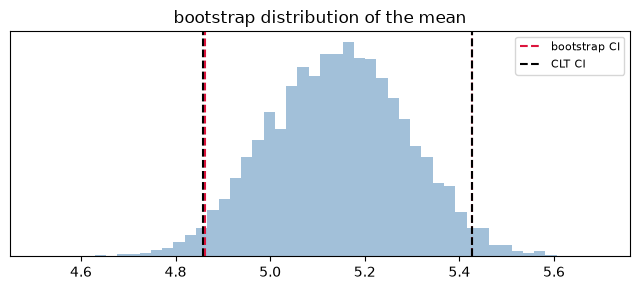

In [3]:
data = rng.normal(5.0, 2.0, 200)
reps = bootstrap(data, np.mean)
boot_lo, boot_hi = ci(reps)
clt_lo, clt_hi = data.mean() - 1.96 * data.std(ddof=1) / np.sqrt(len(data)), \
                 data.mean() + 1.96 * data.std(ddof=1) / np.sqrt(len(data))
print('mean estimate     : %.3f' % data.mean())
print('bootstrap 95%% CI  : [%.3f, %.3f]' % (boot_lo, boot_hi))
print('CLT formula 95%% CI: [%.3f, %.3f]' % (clt_lo, clt_hi))

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.hist(reps, bins=50, density=True, alpha=0.5, color='steelblue')
for v, c, l in [(boot_lo, 'crimson', 'bootstrap CI'), (boot_hi, 'crimson', None),
                (clt_lo, 'k', 'CLT CI'), (clt_hi, 'k', None)]:
    ax.axvline(v, color=c, ls='--', label=l)
ax.set_title('bootstrap distribution of the mean'); ax.legend(fontsize=8); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 3. Where the bootstrap earns its keep

The payoff is statistics with no clean formula. The median and a ratio of means have awkward sampling distributions; a fitted model parameter (here a Poisson rate from `PoissonEstimator`) inherits whatever complexity the model has. The bootstrap handles all three identically - resample, refit, summarize.


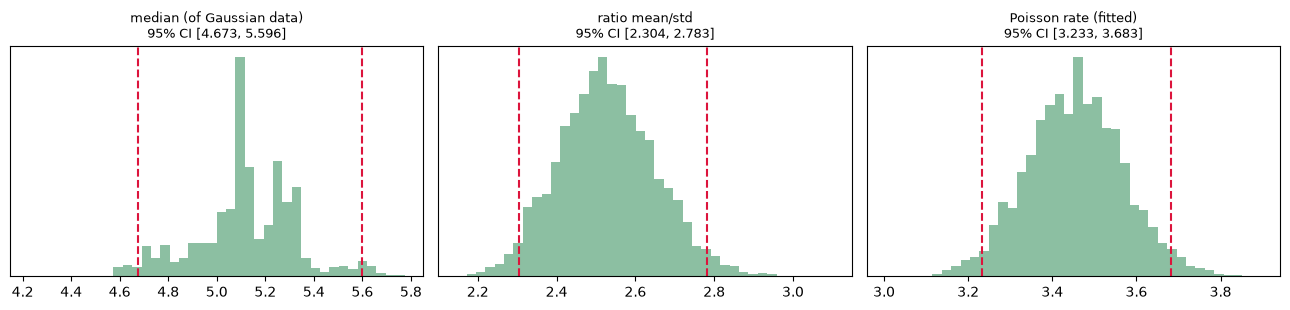

In [4]:
counts = rng.poisson(3.5, 300).astype(float)
def poisson_rate(x):
    est = PoissonEstimator(); acc = est.accumulator_factory().make()
    for v in x: acc.update(float(v), 1.0, None)
    return est.estimate(len(x), acc.value()).lam

stats = {
    'median (of Gaussian data)': bootstrap(data, np.median),
    'ratio mean/std': bootstrap(data, lambda x: x.mean() / x.std()),
    'Poisson rate (fitted)': bootstrap(counts, poisson_rate),
}
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
for a, (name, reps) in zip(ax, stats.items()):
    lo, hi = ci(reps)
    a.hist(reps, bins=40, density=True, alpha=0.55, color='seagreen')
    a.axvline(lo, color='crimson', ls='--'); a.axvline(hi, color='crimson', ls='--')
    a.set_title('%s\n95%% CI [%.3f, %.3f]' % (name, lo, hi), fontsize=9); a.set_yticks([])
plt.tight_layout(); plt.show()

## 4. The BCa interval: the modern default

The percentile interval is biased for skewed statistics. The bias-corrected and accelerated (BCa) interval (DiCiccio & Efron 1996) adjusts the percentile endpoints using a bias correction $\hat z_0$ (how often bootstrap replicates fall below the estimate) and an acceleration $\hat a$ (skewness, from the jackknife). It is the recommended default. We implement it and compare to the plain percentile interval on a skewed statistic (the variance).


In [5]:
from scipy.stats import norm
def bca_ci(x, stat, B=4000, level=0.95):
    x = np.asarray(x); n = len(x); theta = stat(x)
    reps = np.array([stat(x[rng.randint(0, n, n)]) for _ in range(B)])
    z0 = norm.ppf((np.sum(reps < theta) + 0.5) / (B + 1))                 # bias correction
    jk = np.array([stat(np.delete(x, i)) for i in range(n)]); jbar = jk.mean()
    a = np.sum((jbar - jk) ** 3) / (6.0 * (np.sum((jbar - jk) ** 2) ** 1.5) + 1e-300)   # acceleration
    z = norm.ppf([(1 - level) / 2, 1 - (1 - level) / 2])
    pct = norm.cdf(z0 + (z0 + z) / (1 - a * (z0 + z)))
    return np.percentile(reps, 100 * pct)

data2 = rng.gamma(2.0, 2.0, 200)                  # skewed -> percentile and BCa differ
var_stat = lambda x: x.var()
pct = np.percentile([var_stat(data2[rng.randint(0, len(data2), len(data2))]) for _ in range(4000)], [2.5, 97.5])
print('variance estimate: %.3f' % var_stat(data2))
print('percentile 95%% CI: [%.3f, %.3f]' % tuple(pct))
print('BCa        95%% CI: [%.3f, %.3f]  <- shifted to correct for skew' % tuple(bca_ci(data2, var_stat)))

variance estimate: 5.048
percentile 95% CI: [3.899, 6.331]
BCa        95% CI: [4.128, 6.527]  <- shifted to correct for skew


## Illustration: the bootstrap atom for the maximum

We bootstrap the sample maximum of uniform data and measure how often the bootstrap maximum coincides
exactly with the observed maximum. The theory predicts an atom of mass $1-e^{-1}\approx 0.632$, which no
continuous sampling distribution has, so the bootstrap cannot be approximating the truth.

In [6]:
rng = np.random.RandomState(0)
n = 200; theta = 1.0
x = rng.uniform(0, theta, n); theta_hat = x.max()
B = 20000
boot_max = np.array([rng.choice(x, n, replace=True).max() for _ in range(B)])
atom = np.mean(boot_max == theta_hat)
print('P(bootstrap max == observed max) = %.3f   theory 1 - 1/e = %.3f' % (atom, 1 - np.exp(-1)))
# contrast: for the mean the bootstrap SE matches the formula sigma/sqrt(n)
boot_mean = np.array([rng.choice(x, n, replace=True).mean() for _ in range(B)])
print('mean: bootstrap SE = %.4f   formula sd/sqrt(n) = %.4f  (smooth functional: bootstrap works)' %
      (boot_mean.std(), x.std(ddof=1) / np.sqrt(n)))
print('the maximum carries a ~63%% atom at zero error, so its bootstrap is inconsistent; use m-out-of-n.')

P(bootstrap max == observed max) = 0.636   theory 1 - 1/e = 0.632


mean: bootstrap SE = 0.0203   formula sd/sqrt(n) = 0.0201  (smooth functional: bootstrap works)
the maximum carries a ~63%% atom at zero error, so its bootstrap is inconsistent; use m-out-of-n.


## References

- Efron, B. (1979). Bootstrap methods: another look at the jackknife (https://doi.org/10.1214/aos/1176344552). Ann. Statist. 7(1), 1-26. - the original.
- Efron, B. & Tibshirani, R. J. (1993). An Introduction to the Bootstrap. Chapman & Hall.
- DiCiccio, T. J. & Efron, B. (1996). Bootstrap confidence intervals (https://doi.org/10.1214/ss/1032280214). Statist. Sci. 11(3), 189-228. - BCa and percentile-t.
- Davison, A. C. & Hinkley, D. V. (1997). Bootstrap Methods and their Application. Cambridge University Press.


## Exercises and extensions

1. Coverage of four interval types. Implement the percentile, basic (reverse-percentile), bootstrap-$t$, and BCa (bias-corrected and accelerated) intervals for the mean and for a skewed statistic (the variance or a ratio). Over 2000 simulated datasets, measure the empirical coverage and average width of each at the 90% and 95% levels. Rank them and explain why BCa wins for skewed statistics (DiCiccio & Efron).
2. Parametric vs nonparametric bootstrap. For a fitted mixle model, compare the nonparametric bootstrap (resample data) against the parametric bootstrap (simulate from the fitted model and refit). Construct a case where they disagree (heavy tails, small $n$) and explain which is trustworthy.
3. The bootstrap can fail. Demonstrate a known failure mode - bootstrapping the sample maximum of a uniform, or the mean of an infinite-variance Pareto (heavy_tails_and_survival). Show the bootstrap distribution does not converge to the truth, and discuss remedies (the $m$-out-of-$n$ bootstrap, subsampling).
4. Bootstrapping a full pipeline. Wrap a complete fit-and-predict pipeline (e.g. choose $K$ by CV, then fit a mixture) in a bootstrap to get honest uncertainty on a downstream quantity (a predicted probability, a cluster count). Show why bootstrapping only the final step understates uncertainty.
